# Atlas Regions: Brain v. Blood DMPs and DMRs
Use output .tsv files from `make_UXM_overlap_tsvs.py`

##### Modules

In [1]:
import os
import pandas as pd
import glob
import numpy as np
from typing import Optional, Mapping
from pybedtools import BedTool

import seaborn as sb
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Fonts & Colors

In [2]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (15, 10)

# font size
title_size = 16
label_size = 14
tick_size = 12

##### Functions

In [3]:
def get_sig_counts(d, p_col, labels):
    d["sig"] = d[p_col] < 0.05
    
    # Count segments per comparison × DSS overlap
    count_df = (
        d
        .value_counts(["comparison", "sig"])
        .rename("count")
        .reset_index()
    )
    
    # Make labels nicer
    count_df["sig"] = count_df["sig"].map({
        True: labels[0],
        False: labels[1]
    })
    
    # Ensure consistent ordering
    count_df["comparison"] = pd.Categorical(
        count_df["comparison"], categories=sample_pairs, ordered=True
    )
    count_df["sig"] = pd.Categorical(
        count_df["sig"], categories=labels, ordered=True
    )
    
    # Pivot to wide for stacked plotting
    count_wide = (
        count_df
        .pivot(index="comparison", columns="sig", values="count")
        .fillna(0)
        .astype(int)
    )
    return count_wide

In [4]:
def get_TF_counts(d, col, labels):
    # Count segments per comparison × DSS overlap
    count_df = (
        d
        .value_counts(["comparison", col])
        .rename("count")
        .reset_index()
    )
    
    # Make labels nicer
    count_df[col] = count_df[col].map({
        True: labels[0],
        False: labels[1]
    })
    
    # Ensure consistent ordering
    count_df["comparison"] = pd.Categorical(
        count_df["comparison"], categories=sample_pairs, ordered=True
    )
    count_df[col] = pd.Categorical(
        count_df[col], categories=labels, ordered=True
    )
    
    # Pivot to wide for stacked plotting
    count_wide = (
        count_df
        .pivot(index="comparison", columns=col, values="count")
        .fillna(0)
        .astype(int)
    )
    return count_wide

In [5]:
def bin_n_sites(n):
    if n == 1:
        return '1 CpG site'
    elif 2 <= n <= 10:
        return '2–10 CpG sites'
    else:
        return '>10 CpG sites'

In [6]:
def compute_frac_inside_atlas_per_dmr(
    df: pd.DataFrame,
    dmr_cols=("chr", "start", "end", "comparison", "test"),
    n_sites_col="n_sites",
    location_col="location",
    cap_at_n_sites: bool = True,
) -> pd.DataFrame:
    """
    Return ONE row per unique DMR with:
      - n_sites: total CpGs in the DMR
      - n_atlas_cpgs: total CpGs inside atlas regions, summed across all overlaps
      - frac_inside_atlas: n_atlas_cpgs / n_sites

    Assumptions:
      - Input has multiple rows per DMR, typically one per (DMR, atlas-region) pair.
      - Each row represents ONE CpG (or one unit) inside an atlas region for that DMR,
        so counting rows gives atlas CpGs.
      - If a DMR overlaps multiple atlas regions, we add counts across those overlaps.

    Safety:
      - If cap_at_n_sites=True, n_atlas_cpgs is clipped to <= n_sites to guard against
        duplicated rows or double-counting.
    """

    d = df.copy()

    # If location is NA, it contributes 0 atlas CpGs
    d["_atlas_hit"] = d[location_col].notna().astype(int)

    out = (
        d.groupby(list(dmr_cols), as_index=False)
         .agg(
             n_sites=(n_sites_col, "first"),
             n_atlas_cpgs=("_atlas_hit", "sum"),
         )
    )

    # optional guard against accidental double-counting
    if cap_at_n_sites:
        out["n_atlas_cpgs"] = np.minimum(out["n_atlas_cpgs"].astype(int),
                                         out["n_sites"].astype(int))

    out["frac_inside_atlas"] = out["n_atlas_cpgs"] / out["n_sites"]

    return out

##### plotting functions

In [7]:
def plot_grouped_upset_from_counts(
    counts,
    set_sizes=None,
    comparison_order=None,
    colors=None,  # list of colors (len == #comparisons)
    combo_order=("modkit_only", "dss_only", "both"),
    combo_labels=("modkit only", "DSS only", "modkit ∩ DSS"),
    title=None,
    show_left_legend=True,
    # ---- new style controls ----
    label_fs=14,
    tick_fs=12,
    legend_fs=12,
    title_fs=16,
    dot_size=150,
    line_w=2.5,
):
    """Grouped UpSet-style plot for 2 methods (modkit, DSS) across multiple comparisons.

    Input is counts only; optional set_sizes for left panel.

    Parameters
    ----------
    counts : dict
        comp -> dict/tuple of (modkit_only, dss_only, both)
    set_sizes : dict or None
        comp -> (modkit_total, dss_total)  (DMR call counts)
    colors : list or None
        One color per comparison; used in BOTH left and top panels.
    label_fs, tick_fs, legend_fs, title_fs : int
        Font sizes.
    dot_size : int
        Dot size for the membership matrix.
    line_w : float
        Connector line width for intersections.
    """

    if comparison_order is None:
        comparison_order = list(counts.keys())

    nC = len(comparison_order)
    nComb = len(combo_order)

    if colors is None:
        colors = [None] * nC
    elif len(colors) != nC:
        raise ValueError(f"colors must have length {nC} (one per comparison)")

    # ---- Build data matrix for top bars ----
    data = np.zeros((nC, nComb), dtype=float)
    for i, comp in enumerate(comparison_order):
        v = counts[comp]
        if isinstance(v, dict):
            data[i, :] = [v[k] for k in combo_order]
        else:
            if len(v) != nComb:
                raise ValueError(f"{comp}: expected {nComb} values, got {len(v)}")
            data[i, :] = v

    show_left = set_sizes is not None

    fig_w = 10 if show_left else 7.5
    fig = plt.figure(figsize=(fig_w, 6))

    if show_left:
        gs = fig.add_gridspec(
            nrows=2,
            ncols=2,
            width_ratios=[1.4, 3.6],
            height_ratios=[3.0, 1.4],
            wspace=0.25,
            hspace=0.1,  # <-- more vertical space
        )
        ax_set = fig.add_subplot(gs[:, 0])
        ax_bar = fig.add_subplot(gs[0, 1])
        ax_mat = fig.add_subplot(gs[1, 1], sharex=ax_bar)
    else:
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.0, 1.4], hspace=0.1)
        ax_bar = fig.add_subplot(gs[0, 0])
        ax_mat = fig.add_subplot(gs[1, 0], sharex=ax_bar)
        ax_set = None

    # =========================
    # LEFT PANEL: grouped bars with ONLY 2 y ticks (modkit, DSS)
    # =========================
    if show_left:
        modkit_sizes = np.zeros(nC, dtype=float)
        dss_sizes = np.zeros(nC, dtype=float)

        for i, comp in enumerate(comparison_order):
            ss = set_sizes[comp]
            if isinstance(ss, dict):
                modkit_sizes[i] = ss["modkit_total"]
                dss_sizes[i] = ss["dss_total"]
            else:
                if len(ss) != 2:
                    raise ValueError(
                        f"{comp}: set_sizes must have 2 values (modkit_total, dss_total)"
                    )
                modkit_sizes[i], dss_sizes[i] = ss

        # Two groups: y=1 (modkit), y=0 (DSS)
        y_groups = np.array([1.0, 0.0])

        # group height and per-comparison offsets within each group
        total_group_height = 0.75
        bar_h = total_group_height / nC
        offsets = (np.arange(nC) - (nC - 1) / 2.0) * bar_h

        # Plot modkit totals
        for i, comp in enumerate(comparison_order):
            ax_set.barh(
                y_groups[0] + offsets[i],
                modkit_sizes[i],
                height=bar_h * 0.92,
                color=colors[i],
                label=comp if show_left_legend else None,
            )

        # Plot DSS totals
        for i, comp in enumerate(comparison_order):
            ax_set.barh(
                y_groups[1] + offsets[i],
                dss_sizes[i],
                height=bar_h * 0.92,
                color=colors[i],
            )

        ax_set.set_yticks([1.0, 0.0])
        ax_set.set_yticklabels(["modkit", "DSS"], fontsize=tick_fs)
        ax_set.set_xlabel("Set size", fontsize=label_fs)
        ax_set.tick_params(axis="x", labelsize=tick_fs)
        ax_set.spines["top"].set_visible(False)
        ax_set.spines["right"].set_visible(False)
        ax_set.grid(axis="x", linestyle=":", alpha=0.3)

        ax_set.legend(fontsize=legend_fs, bbox_to_anchor=(1.5, -.1))

    # =========================
    # TOP PANEL: grouped intersection bars
    # =========================
    x = np.arange(nComb)
    total_group_width = 0.8
    bar_w = total_group_width / nC
    x_offsets = (np.arange(nC) - (nC - 1) / 2.0) * bar_w

    for i, comp in enumerate(comparison_order):
        ax_bar.bar(
            x + x_offsets[i],
            data[i, :],
            width=bar_w * 0.95,
            label=comp,
            color=colors[i],
        )

    ax_bar.set_ylabel("Intersection size", fontsize=label_fs)
    ax_bar.tick_params(axis="y", labelsize=tick_fs)

    # Remove x ticks/labels from top plot entirely
    ax_bar.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)

    # ax_bar.legend(frameon=False, fontsize=legend_fs)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.grid(axis="y", linestyle=":", alpha=0.4)

    if title:
        ax_bar.set_title(title, fontsize=title_fs, pad=10)

    # =========================
    # BOTTOM PANEL: dot matrix (fixed for 2 sets)
    # =========================
    membership = {
        "modkit_only": (1, 0),
        "dss_only": (0, 1),
        "both": (1, 1),
    }

    for j, combo in enumerate(combo_order):
        m_mod, m_dss = membership[combo]

        ax_mat.scatter([j, j], [1, 0], s=dot_size, color="lightgray", zorder=1)
        if m_mod:
            ax_mat.scatter(j, 1, s=dot_size, color="black", zorder=2)
        if m_dss:
            ax_mat.scatter(j, 0, s=dot_size, color="black", zorder=2)
        if m_mod and m_dss:
            ax_mat.plot([j, j], [0, 1], color="black", linewidth=line_w, zorder=0)

    ax_mat.set_yticks([1, 0])
    ax_mat.set_yticklabels(["modkit", "DSS"], fontsize=tick_fs)
    ax_mat.set_xticks(x)
    ax_mat.set_xticklabels(combo_labels, fontsize=tick_fs)
    ax_mat.set_xlim(-0.5, nComb - 0.5)
    ax_mat.set_ylim(-0.7, 1.7)
    ax_mat.spines["right"].set_visible(False)
    ax_mat.spines["top"].set_visible(False)
    ax_mat.spines["left"].set_visible(False)
    ax_mat.tick_params(axis="y", length=0)

    plt.show()


### Load files

In [8]:
REF_DIR = '/home/eger/software/UXM_deconv/supplemental'
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis/UXM'
DIR2 = DIR1+'/DSS_DMRs'

In [9]:
sample_pairs = [
    "Bulk_FC_Control_02_v_hg002_blood",
    "HBCC_81951_FTX_v_PPMI_3404",
    "HBCC_82044_FTX_v_PPMI_3404"]

#### Atlas file

In [10]:
# load atlas
fname0 = os.path.join(REF_DIR, 'Atlas.U25.Brain_Blood_lifted_to_hg38.tsv')
df0 = pd.read_csv(fname0, sep='\t')

atlas_bt = BedTool.from_dataframe(df0[['chr', 'start', 'end', 'best_group', 'best_dir', 'location']])

#### Chromatin states

In [11]:
STATE_MAP = {
    "1_TssA": "Promoter",
    "2_TssAFlnk": "Promoter",
    "10_TssBiv": "Promoter",
    "6_EnhG": "Enhancer",
    "7_Enh": "Enhancer",
    "12_EnhBiv": "Enhancer",
    "3_TxFlnk": "Gene body",
    "4_Tx": "Gene body",
    "5_TxWk": "Gene body",
    "11_BivFlnk": "Polycomb",
    "13_ReprPC": "Polycomb",
    "14_ReprPCWk": "Polycomb",
    "8_ZNF/Rpts": "Heterochromatin",
    "9_Het": "Heterochromatin",
    "15_Quies": "Quiescent"
}

STATE_PRIORITY = [
    "Promoter",
    "Enhancer",
    "Gene body",
    "Polycomb",
    "Heterochromatin",
    "Quiescent"
]

In [12]:
# collect the files for all cell types/samples
fnames = sorted(glob.glob('/scratch/eger/projects/MethSmoothEval/tissues/ref_data/roadmap_ChromHMM/*15_coreMarks_hg38lift_mnemonics.bed.gz'))

chromhmm_dfs = []
for f in fnames:
    df = pd.read_csv(
        f,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "state"]
    )
    chromhmm_dfs.append(df)

chromhmm_all = pd.concat(chromhmm_dfs, ignore_index=True)
chromhmm_bt = BedTool.from_dataframe(
    chromhmm_all[["chrom", "start", "end", "state"]]
)

Get chromatin states for atlas regions

In [13]:
# intersect with chromatin states
hits = atlas_bt.intersect(chromhmm_bt, wa=True, wb=True)

hits_df = hits.to_dataframe(
    disable_auto_names=True, 
    header=None,
    names=[
        'chr', 'start', 'end', 'best_group', 'best_dir', 'location',
        "chrom2", "start2", "end2", "chromhmm_state"
    ]
)

# collapase into broader classes
hits_df["state_class"] = hits_df["chromhmm_state"].map(STATE_MAP)

# add rank to states
hits_df["state_class"] = pd.Categorical(
    hits_df["state_class"],
    categories=STATE_PRIORITY,
    ordered=True
)

# reduce to one label per CpG
atlas_state = (
    hits_df
    .sort_values("state_class")
    .drop_duplicates("location")
    [["location", "state_class"]]
)

# merge back
df0_chromhmm = df0.merge(atlas_state, on="location", how="left")

#### DMP files

In [14]:
dmp_dict = {}
df_all_CpG = pd.DataFrame()

for pair in sample_pairs:
    fname = os.path.join(DIR1, pair+'.all_CpGs_in_atlas.tsv')
    df = pd.read_csv(fname, sep='\t')

    # add comparison label
    df["comparison"] = pair

    # save the df to the dictionary
    dmp_dict[pair] = df

    # add to full df
    df_all_CpG = pd.concat([df_all_CpG, df], ignore_index=True)

#### DMR files

In [15]:
dmr_dict = {}
shared_cols = ['chr', 'start', 'end', 'n_sites', 'comparison', 'test', 'effect_size', 'stat',
               'best_group', 'best_dir', 'location', 'dir_match_atlas']
    
df_all_dmr = pd.DataFrame()

for pair in sample_pairs:
    fname1 = os.path.join(DIR1, pair+'.segments_in_atlas.tsv')
    fname2 = os.path.join(DIR1, pair+'.DMLtest_DMRs_in_atlas.tsv')
    fname3 = os.path.join(DIR1, pair+'.DMLtestwSmoothing_DMRs_in_atlas.tsv')
    
    df1 = pd.read_csv(fname1, sep='\t')
    df2 = pd.read_csv(fname2, sep='\t')
    df3 = pd.read_csv(fname3, sep='\t')
    
    # subset the different segments
    df1 = df1[df1['state_name'] == 'different']

    # add comparison label
    df1["comparison"] = pair
    df2["comparison"] = pair
    df3["comparison"] = pair

    df1["test"] = 'modkit'
    df2["test"] = 'DSS'
    df3["test"] = 'DSSwSmooth'
    
    # subset and rename cols for merging
    df1 = df1[['chr', 'start', 'end', 'n_sites', 'comparison', 'test', 'effect_size', 'cohen_h', 
               'best_group', 'best_dir', 'location', 'dir_match_atlas']]
    df2 = df2[['chr', 'start', 'end', 'nCG', 'comparison', 'test', 'diff.Methy', 'areaStat', 
               'best_group', 'best_dir', 'location', 'dir_match_atlas']]
    df3 = df3[['chr', 'start', 'end', 'nCG', 'comparison', 'test', 'diff.Methy', 'areaStat',
               'best_group', 'best_dir', 'location', 'dir_match_atlas']]   
    df1.columns = shared_cols
    df2.columns = shared_cols
    df3.columns = shared_cols

    # combine the dataframes
    df = pd.concat([df1, df2, df3], ignore_index=True)

    # save the df to the dictionary
    dmr_dict[pair] = df

    # add to full df
    df_all_dmr = pd.concat([df_all_dmr, df], ignore_index=True)

# add length col
df_all_dmr['length'] = df_all_dmr['end'] - df_all_dmr['start']

In [16]:
# `df_all_dmr` has a row per unique region-atlas pair
# make a df with one row per region
df_all_dmr_frac = compute_frac_inside_atlas_per_dmr(df_all_dmr)

In [17]:
df = compute_frac_inside_atlas_per_dmr(df_all_dmr)

### DMPs in Atlas Regions

#### CpGs in Atlas Regions (bar plots)

##### All 3 tests

In [18]:
# p threshold
alpha = 0.05

# plot settings
plot_title = 'All CpGs in Atlas Regions'
y_label = 'N CpG sites'
ns_color = "lightgray"
dark2 = mpl.colormaps["Dark2"]

tests = {
    "modkit MAP p < 0.05": "map_pvalue",
    "DSS FDR p < 0.05": "DML_pval",
    "DSSwSmooth FDR p < 0.05": "Smooth_DML_pval",
}
# -------------------------
# Colors: tests (Dark2 + Set2), n.s. = light gray
# -------------------------
test_colors = dict(zip(tests.keys(), [dark2(0), dark2(2),dark2(1)]))

comparisons = list(pd.unique(df_all_CpG["comparison"]))

rows = []
for comp in comparisons:
    d = df_all_CpG.loc[df_all_CpG["comparison"] == comp]
    total = len(d)
    for test_name, pcol in tests.items():
        sig = (d[pcol] < alpha).sum()
        ns = total - sig
        rows.append({"comparison": comp, "test": test_name, "n.s.": ns, "p < 0.05": sig})

count_long = pd.DataFrame(rows)
count_wide = (
    count_long.set_index(["comparison", "test"])[["n.s.", "p < 0.05"]]
    .sort_index(level=["comparison", "test"])
)

In [19]:
count_wide

n.s.  p < 0.05
comparison                       test                                   
Bulk_FC_Control_02_v_hg002_blood DSS FDR p < 0.05          863       922
                                 DSSwSmooth FDR p < 0.05   578      1207
                                 modkit MAP p < 0.05       854       931
HBCC_81951_FTX_v_PPMI_3404       DSS FDR p < 0.05          999       777
                                 DSSwSmooth FDR p < 0.05   365      1411
                                 modkit MAP p < 0.05       972       804
HBCC_82044_FTX_v_PPMI_3404       DSS FDR p < 0.05         1086       689
                                 DSSwSmooth FDR p < 0.05   423      1352
                                 modkit MAP p < 0.05      1049       726

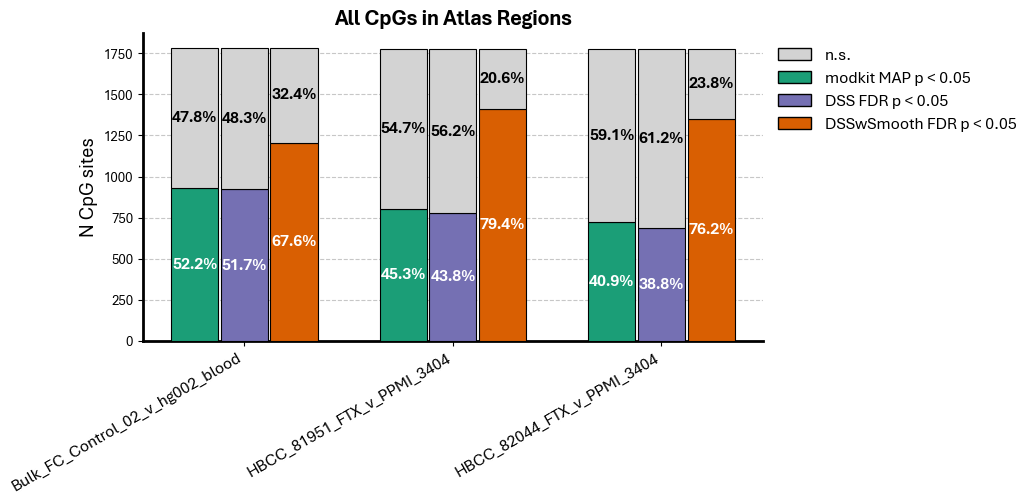

In [20]:
# -------------------------
# Plot: 9 bars total (3 comps x 3 tests), stacked by p<0.05 then n.s.
# -------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_comp = len(comparisons)
test_order = list(tests.keys())
n_tests = len(test_order)

group_gap = 1.2
bar_w = 0.95  # wider bars

x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_tests + group_gap)
    for k, test_name in enumerate(test_order):
        x_positions.append(base + k)

x_positions = np.array(x_positions)

# Reindex in the exact plotting order
plot_index = pd.MultiIndex.from_product([comparisons, test_order], names=["comparison", "test"])
plot_df = count_wide.reindex(plot_index)

totals = plot_df.sum(axis=1).values

# stack p<0.05 FIRST (bottom)
vals_sig = plot_df["p < 0.05"].values
sig_bottom = np.zeros(len(plot_df), dtype=float)

sig_colors = [test_colors[t] for (_, t) in plot_df.index]
ax.bar(
    x_positions,
    vals_sig,
    width=bar_w,
    bottom=sig_bottom,
    color=sig_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# stack n.s. SECOND (top)
vals_ns = plot_df["n.s."].values
ns_bottom = vals_sig
ax.bar(
    x_positions,
    vals_ns,
    width=bar_w,
    bottom=ns_bottom,
    color=ns_color,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# Labels inside stacks (percent)
for i, (sig, ns, t) in enumerate(zip(vals_sig, vals_ns, totals)):
    if t == 0:
        continue

    # bottom label (sig)
    if sig > 0:
        ax.text(
            x_positions[i],
            sig / 2,
            f"{100 * sig / t:.1f}%",
            ha="center",
            va="center",
            fontsize=tick_size,
            fontweight="bold",
            color="white",
            zorder=5,
        )

    # top label (n.s.)
    if ns > 0:
        ax.text(
            x_positions[i],
            sig + ns / 2,
            f"{100 * ns / t:.1f}%",
            ha="center",
            va="center",
            fontsize=tick_size,
            fontweight="bold",
            color="black",
            zorder=5,
        )

# Axis formatting: tick at middle bar of each group
mid = n_tests // 2
ax.set_xticks([x_positions[mid], x_positions[mid + n_tests], x_positions[mid + 2 * n_tests]])
ax.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
ax.set_ylabel(y_label, fontsize=label_size)
ax.set_xlabel("")

if plot_title is not None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

# Legend: n.s. + 3 tests
legend_handles = [Patch(facecolor=ns_color, edgecolor="black", label="n.s.")]
legend_handles += [
    Patch(facecolor=test_colors[name], edgecolor="black", label=f"{name}")
    for name in test_order
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()


In [21]:
# -------------------------
# Settings
# -------------------------
alpha = 0.05
plot_title = "DMPs in Atlas Regions"

# Tests and their p-value columns (bars)
tests = {
    "modkit MAP p < 0.05": "map_pvalue",
    "DSS FDR p < 0.05": "DML_pval",
    "DSSwSmooth FDR p < 0.05": "Smooth_DML_pval",
}

comparisons = list(pd.unique(df_all_CpG["comparison"]))

dark2 = mpl.colormaps["Dark2"]
set2 = mpl.colormaps["Set2"]

test_order = list(tests.keys())
# Colors: dir_match_atlas=True uses Dark2, False uses Set2 (matched by test order)
true_colors = dict(zip(test_order, [dark2(0), dark2(2), dark2(1)]))
false_colors = dict(zip(test_order, [set2(0), set2(2), set2(1)]))

# -------------------------
# Build counts: among significant CpGs for each test,
# stack by dir_match_atlas True/False
# -------------------------
rows = []
for comp in comparisons:
    d = df_all_CpG.loc[df_all_CpG["comparison"] == comp]
    for test_name, pcol in tests.items():
        sig = d[pcol] < alpha
        n_sig = int(sig.sum())

        # within significant, count atlas direction match
        n_true = int((sig & (d["dir_match_atlas"] == True)).sum())
        n_false = int((sig & (d["dir_match_atlas"] == False)).sum())

        rows.append(
            {
                "comparison": comp,
                "test": test_name,
                "Consistent with atlas": n_true,
                "Inconsistent with atlas": n_false,
                "total": n_sig,
            }
        )

count_long = pd.DataFrame(rows)
count_wide = (
    count_long.set_index(["comparison", "test"])[
        ["Consistent with atlas", "Inconsistent with atlas", "total"]
    ]
    .sort_index(level=["comparison", "test"])
)

In [22]:
count_wide

Consistent with atlas   
comparison                       test                                             
Bulk_FC_Control_02_v_hg002_blood DSS FDR p < 0.05                           873  \
                                 DSSwSmooth FDR p < 0.05                   1015   
                                 modkit MAP p < 0.05                        875   
HBCC_81951_FTX_v_PPMI_3404       DSS FDR p < 0.05                           768   
                                 DSSwSmooth FDR p < 0.05                   1228   
                                 modkit MAP p < 0.05                        793   
HBCC_82044_FTX_v_PPMI_3404       DSS FDR p < 0.05                           678   
                                 DSSwSmooth FDR p < 0.05                   1185   
                                 modkit MAP p < 0.05                        713   

                                                          Inconsistent with atlas   
comparison                       test                                               
Bulk_FC_Control_02_v_hg002_blood DSS FDR p < 0.05                              49  \
                                 DSSwSmooth FDR p < 0.05                      191   
                                 modkit MAP p < 0.05                           56   
HBCC_81951_FTX_v_PPMI_3404       DSS FDR p < 0.05                               9   
                                 DSSwSmooth FDR p < 0.05                      172   
                                 modkit MAP p < 0.05                           11   
HBCC_82044_FTX_v_PPMI_3404       DSS FDR p < 0.05                              11   
                                 DSSwSmooth FDR p < 0.05                      123   
                                 modkit MAP p < 0.05                           13   

                                                          total  
comparison                       test                            
Bulk_FC_Control_02_v_hg002_blood DSS FDR p < 0.05           922  
                                 DSSwSmooth FDR p < 0.05   1207  
                                 modkit MAP p < 0.05        931  
HBCC_81951_FTX_v_PPMI_3404       DSS FDR p < 0.05           777  
                                 DSSwSmooth FDR p < 0.05   1411  
                                 modkit MAP p < 0.05        804  
HBCC_82044_FTX_v_PPMI_3404       DSS FDR p < 0.05           689  
                                 DSSwSmooth FDR p < 0.05   1352  
                                 modkit MAP p < 0.05        726

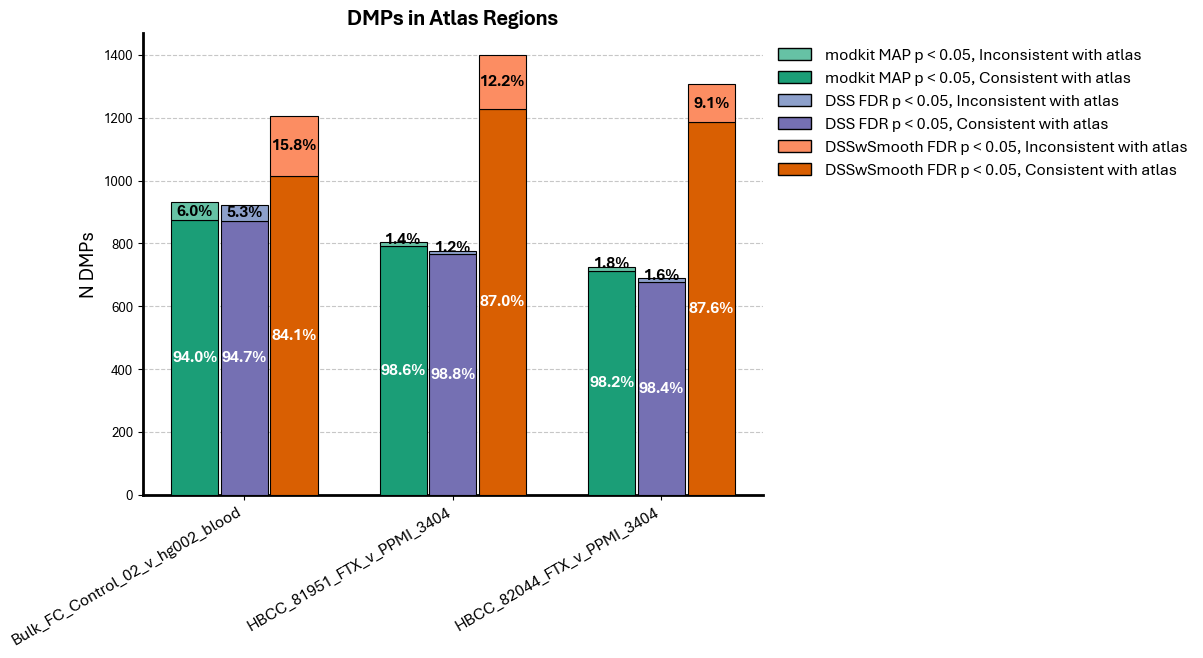

In [23]:
# -------------------------
# Plot: 9 bars total (3 comps x 3 tests)
# stacked True (bottom) then False (top), with % labels
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_tests = len(test_order)
group_gap = 1.2
bar_w = 0.95

x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_tests + group_gap)
    for k, test_name in enumerate(test_order):
        x_positions.append(base + k)

x_positions = np.array(x_positions)

# Reindex in the exact plotting order
plot_index = pd.MultiIndex.from_product(
    [comparisons, test_order], names=["comparison", "test"]
)
plot_df = count_wide.reindex(plot_index)

totals = plot_df["total"].values.astype(float)
vals_true = plot_df["Consistent with atlas"].values.astype(float)
vals_false = plot_df["Inconsistent with atlas"].values.astype(float)

# Bottom stack: True (Dark2 by test)
true_stack_colors = [true_colors[t] for (_, t) in plot_df.index]
ax.bar(
    x_positions,
    vals_true,
    width=bar_w,
    bottom=0,
    color=true_stack_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# Top stack: False (Set2 by test)
false_stack_colors = [false_colors[t] for (_, t) in plot_df.index]
ax.bar(
    x_positions,
    vals_false,
    width=bar_w,
    bottom=vals_true,
    color=false_stack_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# Percent labels inside stacks
for i, (v_true, v_false, t) in enumerate(zip(vals_true, vals_false, totals)):
    if t <= 0:
        continue

    if v_true > 0:
        ax.text(
            x_positions[i],
            v_true / 2,
            f"{100 * v_true / t:.1f}%",
            ha="center",
            va="center",
            fontsize=tick_size,
            fontweight="bold",
            color="white",
            zorder=5,
        )

    if v_false > 0:
        # put % on top if very small
        if (100 * v_false / t) < 3:
            ax.text(
                x_positions[i],
                (v_true + v_false) + 10,
                f"{100 * v_false / t:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5,
            )
        else:
            ax.text(
                x_positions[i],
                v_true + v_false / 2,
                f"{100 * v_false / t:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5,
            )

# Axis formatting: tick at middle bar of each group
mid = n_tests // 2
ax.set_xticks([x_positions[mid], x_positions[mid + n_tests], x_positions[mid + 2 * n_tests]])
ax.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
ax.set_ylabel("N DMPs", fontsize=label_size)
ax.set_xlabel("")

if plot_title is not None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

# Legend: 2 stacks x 3 tests
legend_handles = []
for name in test_order:
    legend_handles.append(
        Patch(facecolor=false_colors[name], edgecolor="black", label=f"{name}, Inconsistent with atlas")
    )
    legend_handles.append(
        Patch(facecolor=true_colors[name], edgecolor="black", label=f"{name}, Consistent with atlas")
    )

ax.legend(handles=legend_handles, bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()


##### Modkit only

In [24]:
plot_title = ''
y_label = 'N CpG sites'
soft_colors = [plt.cm.Dark2.colors[0], plt.cm.Set2.colors[0]]
stack_label_type = 'percent'
count_wide = get_sig_counts(df_all_CpG, 'map_pvalue', ['MAP-based p < 0.05', 'n.s.'])
count_wide

sig,MAP-based p < 0.05,n.s.
comparison,,
Bulk_FC_Control_02_v_hg002_blood,931,854
HBCC_81951_FTX_v_PPMI_3404,804,972
HBCC_82044_FTX_v_PPMI_3404,726,1049


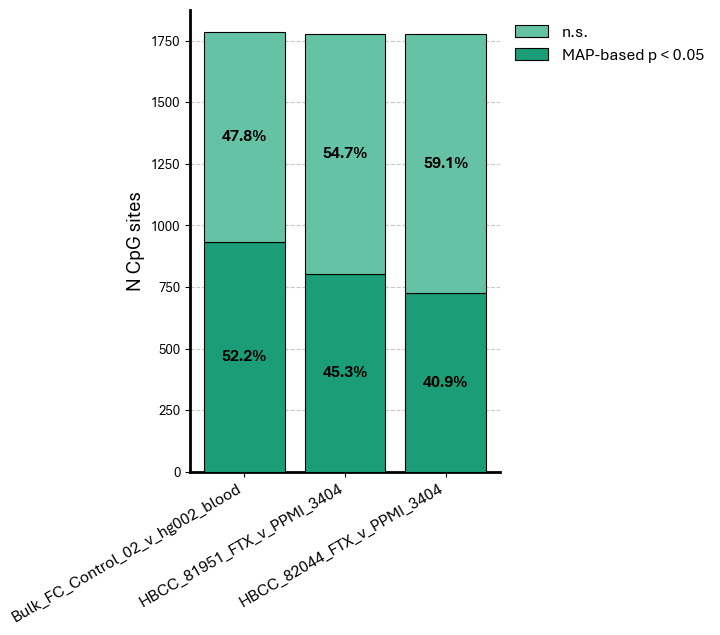

In [25]:
fig, ax = plt.subplots(figsize=(4, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

x = np.arange(count_wide.shape[0])
bottom = np.zeros(count_wide.shape[0])
totals = count_wide.sum(axis=1).values

for i, label in enumerate(count_wide.columns):
    values = count_wide[label].values
        
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=soft_colors[i],
        edgecolor="black",
        linewidth=0.8,
        label=label,
        zorder=4
    )

    # stack labels
    for i, (v, b, t) in enumerate(zip(values, bottom, totals)):
        if v == 0:
            continue
        
        if stack_label_type == 'percent':
            pct = 100 * v / t
            ax.text(
                x[i],
                b + v / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5)
        else:
            ax.text(
                x[i],
                b + v / 2,
                v,
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5)

    bottom += values

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(count_wide.index, rotation=30, ha="right", fontsize=tick_size)
ax.set_ylabel(y_label, fontsize=label_size)
ax.set_xlabel("")

if plot_title != None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()

##### Find washed out DMP examples

In [28]:
# atlas regions in promoters
promoter_atlas_locs = set(df0_chromhmm[(df0_chromhmm['state_class'] == 'Promoter')]['location'])
print(len(promoter_atlas_locs))

enhancer_atlas_locs = set(df0_chromhmm[(df0_chromhmm['state_class'] == 'Enhancer')]['location'])
print(len(enhancer_atlas_locs))

# atlas regions that overlapping with a smooth DMR (correct direction)
smooth_atlas_locs = set(df_all_dmr[(df_all_dmr['test'] == 'DSSwSmooth') &
                                (df_all_dmr['dir_match_atlas'])]['location'])
print(len(smooth_atlas_locs))

print(len(promoter_atlas_locs & smooth_atlas_locs))

80
98
122
57


Promoters

In [29]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(promoter_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'Bulk_FC_Control_02_v_hg002_blood') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head(20)

4


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas
687,chr14,106200783,106200784,0.159104,0.334461,Blood-T,hypo,chr14:106200669-106200796,True
478,chr12,64613991,64613992,0.179381,0.297895,Blood-B,hypo,chr12:64613820-64613993,True
262,chr11,33198050,33198051,0.207778,0.250272,Blood-Mono+Macro,hypo,chr11:33197976-33198159,True
616,chr14,22459557,22459558,0.233968,0.458030,Blood-NK,hypo,chr14:22458516-22459559,True


In [30]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(promoter_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'HBCC_81951_FTX_v_PPMI_3404') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head()

2


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas
3008,chr2,231528629,231528630,0.472222,-1.646304,Blood-NK,hypo,chr2:231528485-231529106,True
2994,chr2,121287587,121287588,0.753788,-2.304729,Blood-Mono+Macro,hypo,chr2:121287283-121287589,True


In [31]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(promoter_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'HBCC_82044_FTX_v_PPMI_3404') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head()

1


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas
4769,chr2,121287587,121287588,0.717105,-2.185691,Blood-Mono+Macro,hypo,chr2:121287283-121287589,True


Enhancers

In [70]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(enhancer_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'Bulk_FC_Control_02_v_hg002_blood') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head(20)

4


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas
1534,chr6,166335219,166335220,0.188955,0.338788,Blood-NK,hypo,chr6:166335023-166335282,True
1178,chr19,53845889,53845890,0.258182,0.357701,Blood-Mono+Macro,hypo,chr19:53845768-53845907,True
1422,chr3,185685773,185685774,0.259231,0.337192,Blood-Mono+Macro,hypo,chr3:185685272-185685775,True
1777,chrY,7326387,7326388,0.487469,0.535859,Blood-T,hypo,chrY:7326350-7327182,True


In [32]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(enhancer_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'HBCC_81951_FTX_v_PPMI_3404') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head(20)

0


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas


In [33]:
df_search = df_all_CpG[(df_all_CpG['location'].isin(enhancer_atlas_locs)) &
            (~df_all_CpG['location'].isin(smooth_atlas_locs)) &
            (df_all_CpG['DML_fdr'] < 0.05) & 
            (df_all_CpG['Smooth_DML_fdr'] > 0.05) &
            (df_all_CpG['map_pvalue'] < 0.05) & 
            (df_all_CpG['comparison'] == 'HBCC_82044_FTX_v_PPMI_3404') &
            (df_all_CpG['dir_match_atlas'])]

print(df_search.shape[0])
df_search[['chr', 'start', 'end', 'effect_size', 'cohen_h_low', 'best_group', 'best_dir',
       'location', 'dir_match_atlas']].sort_values('effect_size').head(20)

0


,chr,start,end,effect_size,cohen_h_low,best_group,best_dir,location,dir_match_atlas


#### CpGs in Atlas Regions (upset plots)

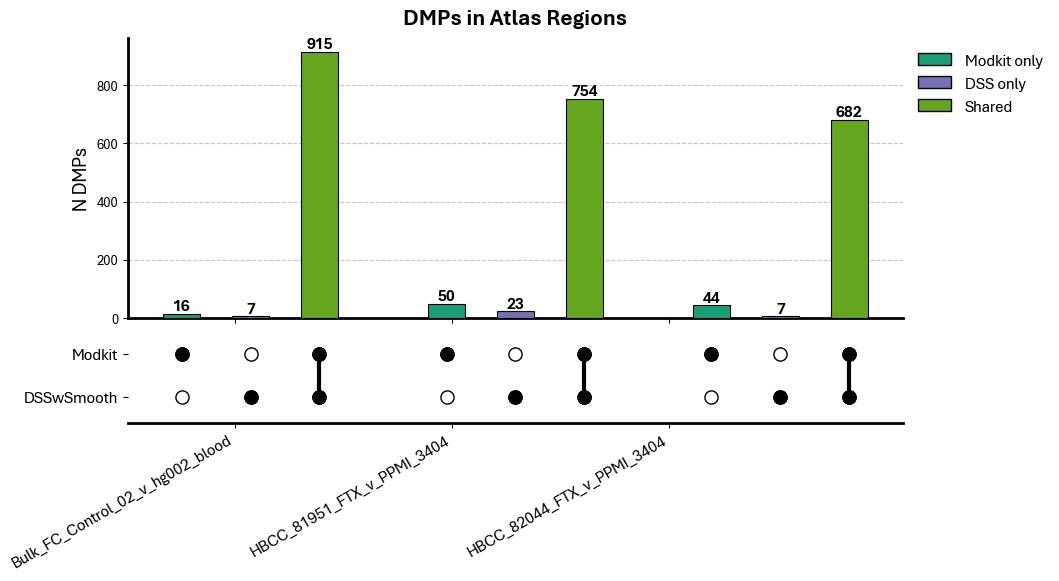

In [71]:
# -------------------------
# Settings
# -------------------------
alpha = 0.05
plot_title = "DMPs in Atlas Regions"

# categories + colors
cat_order = ["Modkit only", "DSS only", "Shared"]
cat_colors = {
    "Modkit only": plt.cm.Dark2.colors[0],
    "DSS only": plt.cm.Dark2.colors[2],
    "Shared": plt.cm.Dark2.colors[4],
}

# which p-value columns define significance
modkit_col = "map_pvalue"
smooth_col = "DML_pval"

# -------------------------
# Build counts (per comparison)
# -------------------------
comparisons = list(pd.unique(df_all_CpG["comparison"]))

rows = []
for comp in comparisons:
    d = df_all_CpG.loc[df_all_CpG["comparison"] == comp].copy()

    modkit_sig = d[modkit_col] < alpha
    smooth_sig = d[smooth_col] < alpha

    rows.append(
        {
            "comparison": comp,
            "Modkit only": int((modkit_sig & ~smooth_sig).sum()),
            "DSS only": int((~modkit_sig & smooth_sig).sum()),
            "Shared": int((modkit_sig & smooth_sig).sum()),
        }
    )

counts = pd.DataFrame(rows).set_index("comparison").reindex(comparisons)

# -------------------------
# UpSet-style plot: bars + membership matrix underneath
# (2 sets: Modkit, DSSwSmooth)
# -------------------------
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.5, 1.2], hspace=0.05)
ax_bar = fig.add_subplot(gs[0])
ax_mat = fig.add_subplot(gs[1], sharex=ax_bar)

# Styling (match your other plots)
for ax in [ax_bar, ax_mat]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)

ax_bar.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_comp = len(comparisons)
n_cat = len(cat_order)

intra_gap = 1.3
group_gap = 1.1
bar_w = 0.7

x_positions = []
bar_vals = []
bar_colors = []
bar_cats = []

for j, comp in enumerate(comparisons):
    base = j * (n_cat + group_gap)
    for k, cat in enumerate(cat_order):
        x_positions.append(base + k)
        bar_vals.append(counts.loc[comp, cat])
        bar_colors.append(cat_colors[cat])
        bar_cats.append(cat)

#x_positions = np.array(x_positions)
x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_tests * intra_gap + group_gap)
    for k, test_name in enumerate(test_order):
        x_positions.append(base + k * intra_gap)

bar_vals = np.array(bar_vals)

# Bars
ax_bar.bar(
    x_positions,
    bar_vals,
    width=bar_w,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

# Optional value labels
for x, v in zip(x_positions, bar_vals):
    if v > 0:
        ax_bar.text(
            x, v,
            f"{v:,}",
            ha="center", va="bottom",
            fontsize=tick_size,
            fontweight="bold",
        )

ax_bar.set_ylabel("N DMPs", fontsize=label_size)
ax_bar.set_title(plot_title, fontsize=title_size, fontweight="bold", pad=10)

# X ticks centered per comparison group
mid = n_cat // 2
centers = np.array([j * (n_cat + group_gap) + mid for j in range(n_comp)])
ax_bar.set_xticks(centers)
ax_bar.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
plt.setp(ax_bar.get_xticklabels(), visible=False)  # hide on top axis (show on matrix axis)

# -------------------------
# Membership matrix (2 rows)
# -------------------------
ax_mat.set_yticks([1, 0])
ax_mat.set_yticklabels(["Modkit", "DSSwSmooth"], fontsize=tick_size)
ax_mat.set_ylim(-0.6, 1.6)

# no y-grid; keep clean
ax_mat.grid(False)
ax_mat.spines["left"].set_visible(False)
ax_mat.spines["bottom"].set_linewidth(2)

# map each category to membership (Modkit row=1, Smooth row=0)
membership = {
    "Modkit only": (True, False),
    "DSS only": (False, True),
    "Shared": (True, True),
}

dot_size = 90
line_w = 3

for x, cat in zip(x_positions, bar_cats):
    m_modkit, m_smooth = membership[cat]

    # background faint dots (optional; comment out if you want only filled dots)
    ax_mat.scatter([x, x], [1, 0], s=dot_size, facecolor="white",
                   edgecolor="black", linewidth=1, zorder=1)

    # filled dots for membership
    if m_modkit:
        ax_mat.scatter(x, 1, s=dot_size, facecolor="black", edgecolor="black", zorder=2)
    if m_smooth:
        ax_mat.scatter(x, 0, s=dot_size, facecolor="black", edgecolor="black", zorder=2)

    # connecting line for shared
    if m_modkit and m_smooth:
        ax_mat.plot([x, x], [0, 1], color="black", linewidth=line_w, zorder=1)

# comparison labels on bottom axis
ax_mat.set_xticks(centers)
ax_mat.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)

# Legend (category colors)
legend_handles = [
    Patch(facecolor=cat_colors[c], edgecolor="black", label=c) for c in cat_order
]
ax_bar.legend(handles=legend_handles, bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()

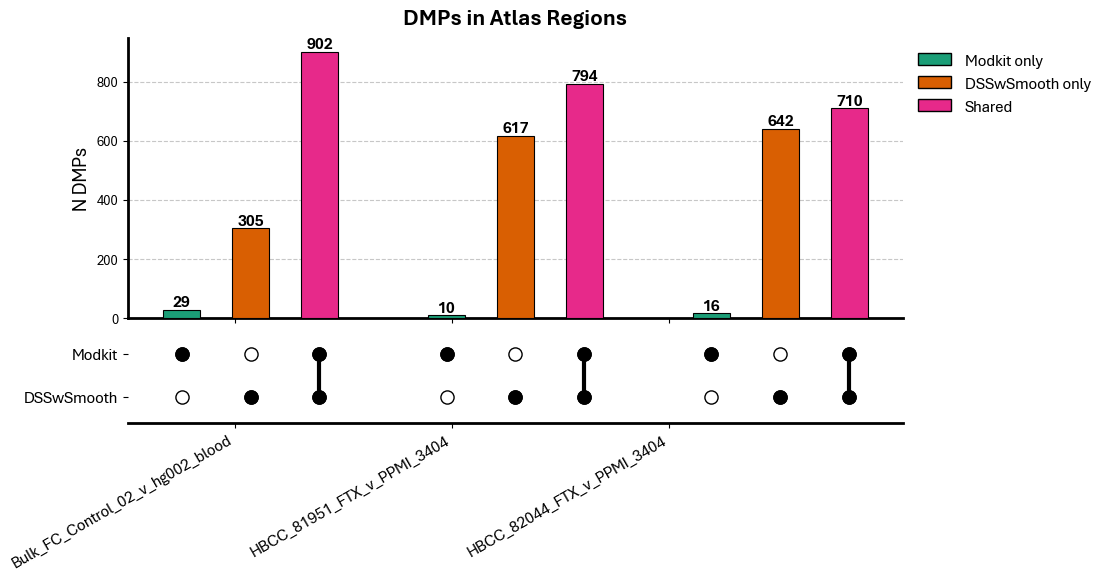

In [72]:
# -------------------------
# Settings
# -------------------------
alpha = 0.05
plot_title = "DMPs in Atlas Regions"

# categories + colors
cat_order = ["Modkit only", "DSSwSmooth only", "Shared"]
cat_colors = {
    "Modkit only": plt.cm.Dark2.colors[0],
    "DSSwSmooth only": plt.cm.Dark2.colors[1],
    "Shared": plt.cm.Dark2.colors[3],
}

# which p-value columns define significance
modkit_col = "map_pvalue"
smooth_col = "Smooth_DML_pval"

# -------------------------
# Build counts (per comparison)
# -------------------------
comparisons = list(pd.unique(df_all_CpG["comparison"]))

rows = []
for comp in comparisons:
    d = df_all_CpG.loc[df_all_CpG["comparison"] == comp].copy()

    modkit_sig = d[modkit_col] < alpha
    smooth_sig = d[smooth_col] < alpha

    rows.append(
        {
            "comparison": comp,
            "Modkit only": int((modkit_sig & ~smooth_sig).sum()),
            "DSSwSmooth only": int((~modkit_sig & smooth_sig).sum()),
            "Shared": int((modkit_sig & smooth_sig).sum()),
        }
    )

counts = pd.DataFrame(rows).set_index("comparison").reindex(comparisons)

# -------------------------
# UpSet-style plot: bars + membership matrix underneath
# (2 sets: Modkit, DSSwSmooth)
# -------------------------
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.5, 1.2], hspace=0.05)
ax_bar = fig.add_subplot(gs[0])
ax_mat = fig.add_subplot(gs[1], sharex=ax_bar)

# Styling (match your other plots)
for ax in [ax_bar, ax_mat]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)

ax_bar.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_comp = len(comparisons)
n_cat = len(cat_order)

intra_gap = 1.3
group_gap = 1.1
bar_w = 0.7

x_positions = []
bar_vals = []
bar_colors = []
bar_cats = []

for j, comp in enumerate(comparisons):
    base = j * (n_cat + group_gap)
    for k, cat in enumerate(cat_order):
        x_positions.append(base + k)
        bar_vals.append(counts.loc[comp, cat])
        bar_colors.append(cat_colors[cat])
        bar_cats.append(cat)

#x_positions = np.array(x_positions)
x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_tests * intra_gap + group_gap)
    for k, test_name in enumerate(test_order):
        x_positions.append(base + k * intra_gap)

bar_vals = np.array(bar_vals)

# Bars
ax_bar.bar(
    x_positions,
    bar_vals,
    width=bar_w,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

# Optional value labels
for x, v in zip(x_positions, bar_vals):
    if v > 0:
        ax_bar.text(
            x, v,
            f"{v:,}",
            ha="center", va="bottom",
            fontsize=tick_size,
            fontweight="bold",
        )

ax_bar.set_ylabel("N DMPs", fontsize=label_size)
ax_bar.set_title(plot_title, fontsize=title_size, fontweight="bold", pad=10)

# X ticks centered per comparison group
mid = n_cat // 2
centers = np.array([j * (n_cat + group_gap) + mid for j in range(n_comp)])
ax_bar.set_xticks(centers)
ax_bar.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
plt.setp(ax_bar.get_xticklabels(), visible=False)  # hide on top axis (show on matrix axis)

# -------------------------
# Membership matrix (2 rows)
# -------------------------
ax_mat.set_yticks([1, 0])
ax_mat.set_yticklabels(["Modkit", "DSSwSmooth"], fontsize=tick_size)
ax_mat.set_ylim(-0.6, 1.6)

# no y-grid; keep clean
ax_mat.grid(False)
ax_mat.spines["left"].set_visible(False)
ax_mat.spines["bottom"].set_linewidth(2)

# map each category to membership (Modkit row=1, Smooth row=0)
membership = {
    "Modkit only": (True, False),
    "DSSwSmooth only": (False, True),
    "Shared": (True, True),
}

dot_size = 90
line_w = 3

for x, cat in zip(x_positions, bar_cats):
    m_modkit, m_smooth = membership[cat]

    # background faint dots (optional; comment out if you want only filled dots)
    ax_mat.scatter([x, x], [1, 0], s=dot_size, facecolor="white",
                   edgecolor="black", linewidth=1, zorder=1)

    # filled dots for membership
    if m_modkit:
        ax_mat.scatter(x, 1, s=dot_size, facecolor="black", edgecolor="black", zorder=2)
    if m_smooth:
        ax_mat.scatter(x, 0, s=dot_size, facecolor="black", edgecolor="black", zorder=2)

    # connecting line for shared
    if m_modkit and m_smooth:
        ax_mat.plot([x, x], [0, 1], color="black", linewidth=line_w, zorder=1)

# comparison labels on bottom axis
ax_mat.set_xticks(centers)
ax_mat.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)

# Legend (category colors)
legend_handles = [
    Patch(facecolor=cat_colors[c], edgecolor="black", label=c) for c in cat_order
]
ax_bar.legend(handles=legend_handles, bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()

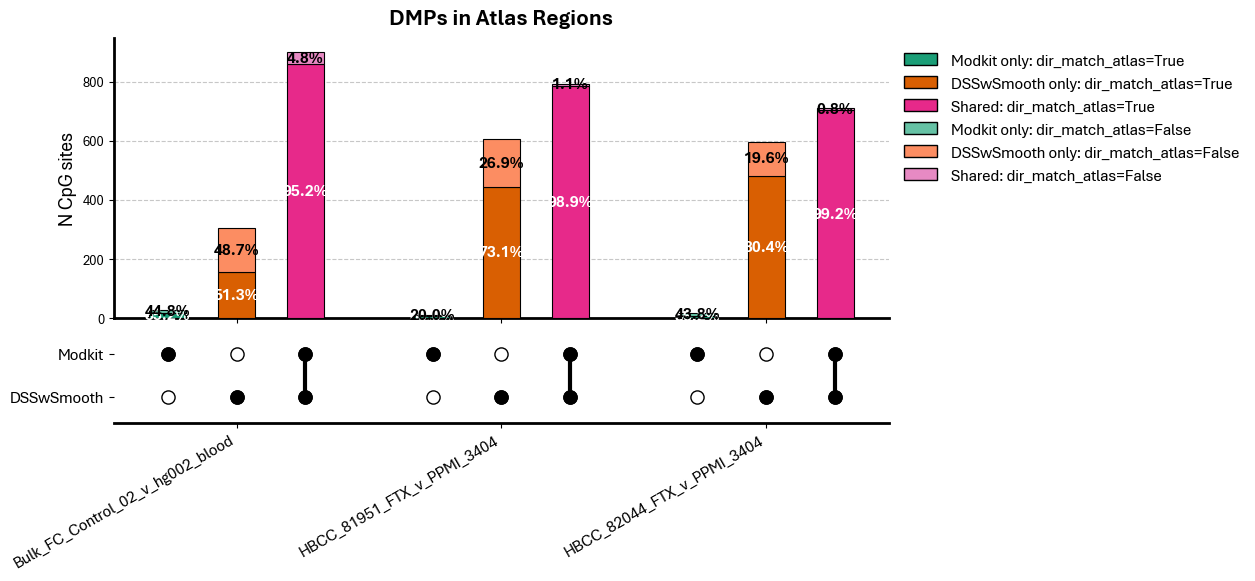

In [73]:
# -------------------------
# Settings
# -------------------------
alpha = 0.05
plot_title = "DMPs in Atlas Regions"

cat_order = ["Modkit only", "DSSwSmooth only", "Shared"]

# which p-value columns define significance
modkit_col = "map_pvalue"
smooth_col = "Smooth_DML_pval"

comparisons = list(pd.unique(df_all_CpG["comparison"]))

# Palettes for stacks
dark2 = mpl.colormaps["Dark2"]
set2  = mpl.colormaps["Set2"]

# One color per category, but True uses Dark2, False uses Set2
cat_true_colors = {
    "Modkit only": dark2(0),
    "DSSwSmooth only": dark2(1),
    "Shared": dark2(3),
}
cat_false_colors = {
    "Modkit only": set2(0),
    "DSSwSmooth only": set2(1),
    "Shared": set2(3),
}

# -------------------------
# Build stacked counts (per comparison x category)
# -------------------------
rows = []
for comp in comparisons:
    d = df_all_CpG.loc[df_all_CpG["comparison"] == comp].copy()

    modkit_sig = d[modkit_col] < alpha
    smooth_sig = d[smooth_col] < alpha

    masks = {
        "Modkit only": (modkit_sig & ~smooth_sig),
        "DSSwSmooth only": (~modkit_sig & smooth_sig),
        "Shared": (modkit_sig & smooth_sig),
    }

    for cat, m in masks.items():
        # within this category, count dir_match_atlas True/False
        n_true = int((m & (d["dir_match_atlas"] == True)).sum())
        n_false = int((m & (d["dir_match_atlas"] == False)).sum())
        rows.append(
            {
                "comparison": comp,
                "category": cat,
                "dir_true": n_true,
                "dir_false": n_false,
                "total": n_true + n_false,
            }
        )

stack_df = pd.DataFrame(rows).set_index(["comparison", "category"]).reindex(
    pd.MultiIndex.from_product([comparisons, cat_order], names=["comparison", "category"])
)

# -------------------------
# UpSet-style plot: bars + membership matrix underneath
# -------------------------
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.5, 1.2], hspace=0.05)
ax_bar = fig.add_subplot(gs[0])
ax_mat = fig.add_subplot(gs[1], sharex=ax_bar)

# Styling
for ax in [ax_bar, ax_mat]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)

ax_bar.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_comp = len(comparisons)
n_cat = len(cat_order)

intra_gap = 1.3
group_gap = 1.1
bar_w = 0.7

# x positions (3 bars per comparison)
x_positions = []
bar_cats = []
for j, comp in enumerate(comparisons):
    base = j * (n_cat * intra_gap + group_gap)
    for k, cat in enumerate(cat_order):
        x_positions.append(base + k * intra_gap)
        bar_cats.append(cat)

x_positions = np.array(x_positions)

# Pull values in plotting order
vals_true = stack_df["dir_true"].values.astype(float)
vals_false = stack_df["dir_false"].values.astype(float)
totals = stack_df["total"].values.astype(float)

# Stacked bars: True bottom, False top
true_colors = [cat_true_colors[c] for c in bar_cats]
false_colors = [cat_false_colors[c] for c in bar_cats]

ax_bar.bar(
    x_positions, vals_true, width=bar_w, bottom=0,
    color=true_colors, edgecolor="black", linewidth=0.8, zorder=3
)
ax_bar.bar(
    x_positions, vals_false, width=bar_w, bottom=vals_true,
    color=false_colors, edgecolor="black", linewidth=0.8, zorder=3
)

# % labels inside stacks (instead of counts at top)
for x, v_t, v_f, t in zip(x_positions, vals_true, vals_false, totals):
    if t <= 0:
        continue
    if v_t > 0:
        ax_bar.text(
            x, v_t / 2, f"{100*v_t/t:.1f}%",
            ha="center", va="center",
            fontsize=tick_size, fontweight="bold",
            color="white", zorder=4
        )
    if v_f > 0:
        ax_bar.text(
            x, v_t + v_f / 2, f"{100*v_f/t:.1f}%",
            ha="center", va="center",
            fontsize=tick_size, fontweight="bold",
            color="black", zorder=4
        )

ax_bar.set_ylabel("N CpG sites", fontsize=label_size)
ax_bar.set_title(plot_title, fontsize=title_size, fontweight="bold", pad=10)

# X ticks centered per comparison group
mid = (n_cat - 1) / 2
centers = np.array([j * (n_cat * intra_gap + group_gap) + mid * intra_gap for j in range(n_comp)])
ax_bar.set_xticks(centers)
ax_bar.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
plt.setp(ax_bar.get_xticklabels(), visible=False)  # hide on top axis

# -------------------------
# Membership matrix (2 rows)
# -------------------------
ax_mat.set_yticks([1, 0])
ax_mat.set_yticklabels(["Modkit", "DSSwSmooth"], fontsize=tick_size)
ax_mat.set_ylim(-0.6, 1.6)

ax_mat.grid(False)
ax_mat.spines["left"].set_visible(False)
ax_mat.spines["bottom"].set_linewidth(2)

membership = {
    "Modkit only": (True, False),
    "DSSwSmooth only": (False, True),
    "Shared": (True, True),
}

dot_size = 90
line_w = 3

for x, cat in zip(x_positions, bar_cats):
    m_modkit, m_smooth = membership[cat]

    ax_mat.scatter([x, x], [1, 0], s=dot_size, facecolor="white",
                   edgecolor="black", linewidth=1, zorder=1)

    if m_modkit:
        ax_mat.scatter(x, 1, s=dot_size, facecolor="black", edgecolor="black", zorder=2)
    if m_smooth:
        ax_mat.scatter(x, 0, s=dot_size, facecolor="black", edgecolor="black", zorder=2)

    if m_modkit and m_smooth:
        ax_mat.plot([x, x], [0, 1], color="black", linewidth=line_w, zorder=1)

ax_mat.set_xticks(centers)
ax_mat.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)

# Legend: category x dir_match_atlas True/False
legend_handles = []
for c in cat_order:
    legend_handles.append(Patch(facecolor=cat_true_colors[c], edgecolor="black", label=f"{c}: dir_match_atlas=True"))
for c in cat_order:
    legend_handles.append(Patch(facecolor=cat_false_colors[c], edgecolor="black", label=f"{c}: dir_match_atlas=False"))

ax_bar.legend(handles=legend_handles, bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()

In [74]:
print(df_all_CpG.shape[0])
print(df_all_CpG[df_all_CpG['map_pvalue'] < 0.05].shape[0])
print(df_all_CpG[df_all_CpG['DML_fdr'] < 0.05].shape[0])
print(df_all_CpG[(df_all_CpG['map_pvalue'] < 0.05) & (df_all_CpG['DML_fdr'] < 0.05)].shape[0])

5336
2461
1675
1675


In [75]:
print(df_all_CpG[df_all_CpG['map_pvalue'] < 0.05].shape[0])
print(df_all_CpG[df_all_CpG['Smooth_DML_fdr'] < 0.05].shape[0])
print(df_all_CpG[(df_all_CpG['map_pvalue'] < 0.05) & (df_all_CpG['Smooth_DML_fdr'] < 0.05)].shape[0])

2461
3658
2381


### DMRs in Atlas Regions

#### N sites per DMR

In [83]:
df_all_dmr.sort_values('n_sites')

,chr,start,end,n_sites,comparison,test,effect_size,stat,best_group,best_dir,location,dir_match_atlas,length
451,chr14,22459557,22459558,1,HBCC_82044_FTX_v_PPMI_3404,modkit,0.705882,1.995186,Blood-NK,hypo,chr14:22458516-22459559,True,1
286,chr5,39202156,39202157,1,HBCC_81951_FTX_v_PPMI_3404,modkit,0.769886,1.762768,Blood-T,hypo,chr5:39201854-39202719,True,1
5,chr1,173886547,173886548,1,Bulk_FC_Control_02_v_hg002_blood,modkit,0.235294,1.012889,Blood-Granul,hypo,chr1:173885684-173886549,True,1
17,chr11,118339870,118339871,1,Bulk_FC_Control_02_v_hg002_blood,modkit,-0.424793,-1.058009,Blood-T,hypo,chr11:118339444-118340659,False,1
482,chr5,39202156,39202157,1,HBCC_82044_FTX_v_PPMI_3404,modkit,0.835859,2.050240,Blood-T,hypo,chr5:39201854-39202719,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,chr8,26579911,26590852,178,HBCC_81951_FTX_v_PPMI_3404,DSSwSmooth,-0.553469,-2086.029563,Neuron:Oligodend,hypo,chr8:26581229-26581617,True,10941
235,chr8,26579911,26591643,188,Bulk_FC_Control_02_v_hg002_blood,DSSwSmooth,-0.562302,-2863.154386,Neuron:Oligodend,hypo,chr8:26588597-26589295,True,11732
236,chr8,26579911,26591643,188,Bulk_FC_Control_02_v_hg002_blood,DSSwSmooth,-0.562302,-2863.154386,Neuron:Oligodend,hypo,chr8:26581229-26581617,True,11732
358,chr12,122840568,122849030,216,HBCC_81951_FTX_v_PPMI_3404,DSSwSmooth,-0.421131,-2336.236269,Oligodend,hypo,chr12:122848344-122848489,True,8462


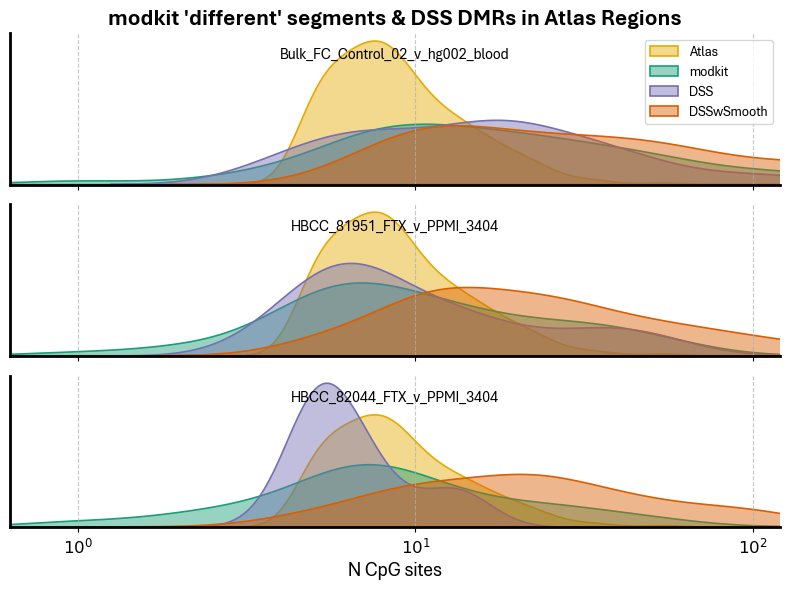

In [81]:
plot_title = "modkit 'different' segments & DSS DMRs in Atlas Regions"
test_order = ["modkit", "DSS", "DSSwSmooth"]
dark2 = mpl.colormaps["Dark2"]
colors = dict(zip(test_order, [dark2(0), dark2(2), dark2(1)]))

plot_df = df_all_dmr[["comparison", "test", "n_sites"]].copy()

# KDE in log10 space
plot_df["log10_n_sites"] = np.log10(plot_df["n_sites"].clip(lower=1))

fig, axes = plt.subplots(
    nrows=len(sample_pairs),
    ncols=1,
    figsize=(8, 2 * len(sample_pairs)),
    sharex=True)

if len(sample_pairs) == 1:
    axes = [axes]

for ax, comp in zip(axes, sample_pairs):
    # ---- styling ----
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)
    ax.set_yticks([])
    ax.set_ylabel("")

    # atlas region distribution
    sb.kdeplot(
        x=np.log10(df0['n_cpgs'].clip(lower=1)),
        ax=ax,
        color=dark2(5),
        fill=True,
        alpha=0.45,
        linewidth=1.2,
        common_norm=False,
        label='Atlas')
    
    sub = plot_df[plot_df["comparison"] == comp]
    for i, test in enumerate(test_order):
        s = sub.loc[sub["test"] == test, "log10_n_sites"]
        if len(s) < 2:
            continue

        sb.kdeplot(
            x=s,
            ax=ax,
            color=colors[test],
            fill=True,
            alpha=0.45,
            linewidth=1.2,
            common_norm=False,
            label=test)


    # comparison label centered at top of subplot
    ax.text(0.5, 0.9,
            comp,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=11)

axes[0].legend(loc="upper right")

# ---- x-axis formatting ----
axes[-1].set_xlabel("N CpG sites", fontsize=label_size)
axes[-1].set_xlim(-0.2, np.log10(1.2e2))
ticks = np.arange(0, 3) 
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([rf"$10^{t}$" for t in ticks], fontsize=tick_size)

if plot_title is not None:
    axes[0].set_title(plot_title, fontweight="bold", fontsize=title_size)

plt.tight_layout()
plt.show()

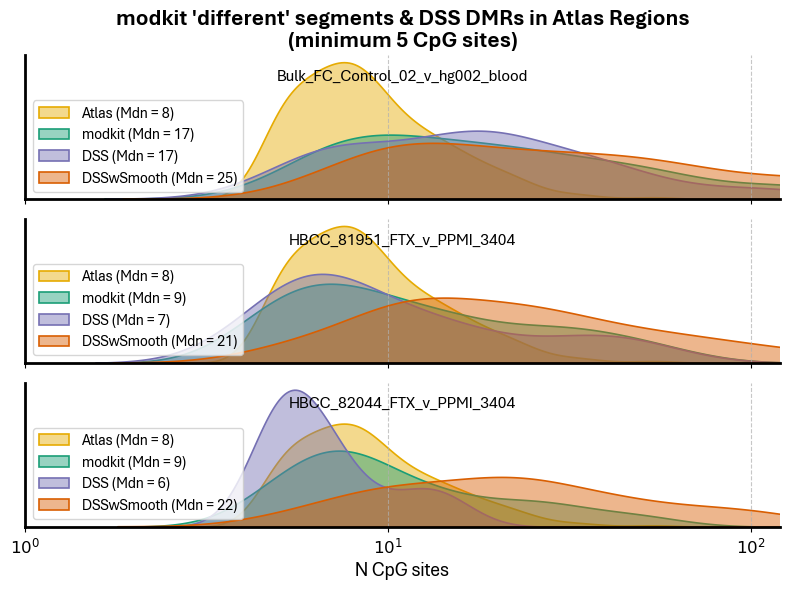

In [89]:
plot_title = ("modkit 'different' segments & DSS DMRs in Atlas Regions"+
              "\n(minimum 5 CpG sites)")
test_order = ["modkit", "DSS", "DSSwSmooth"]
dark2 = mpl.colormaps["Dark2"]
colors = dict(zip(test_order, [dark2(0), dark2(2), dark2(1)]))

plot_df = df_all_dmr[["comparison", "test", "n_sites", "length"]].copy()
plot_df = plot_df[(plot_df['n_sites'] >= 5)]

# KDE in log10 space
plot_df["log10_n_sites"] = np.log10(plot_df["n_sites"].clip(lower=1))

fig, axes = plt.subplots(
    nrows=len(sample_pairs),
    ncols=1,
    figsize=(8, 2 * len(sample_pairs)),
    sharex=True)

if len(sample_pairs) == 1:
    axes = [axes]

for ax, comp in zip(axes, sample_pairs):
    # ---- styling ----
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.grid(True, axis='x', linestyle='--', alpha=0.7, zorder=0)
    ax.set_yticks([])
    ax.set_ylabel("")

    # atlas region distribution
    sb.kdeplot(
        x=np.log10(df0['n_cpgs'].clip(lower=1)),
        ax=ax,
        color=dark2(5),
        fill=True,
        alpha=0.45,
        linewidth=1.2,
        common_norm=False,
        label=f"Atlas (Mdn = {int(df0['n_cpgs'].median())})")
    
    sub = plot_df[plot_df["comparison"] == comp]
    for i, test in enumerate(test_order):
        s = sub.loc[sub["test"] == test, "log10_n_sites"]
        mdn = int(sub.loc[sub["test"] == test, "n_sites"].median())
        if len(s) < 2:
            continue

        sb.kdeplot(
            x=s,
            ax=ax,
            color=colors[test],
            fill=True,
            alpha=0.45,
            linewidth=1.2,
            common_norm=False,
            label=test+f" (Mdn = {mdn})")



    # comparison label centered at top of subplot
    ax.text(0.5, 0.9,
            comp,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=tick_size)

    ax.legend(loc="lower left", fontsize=tick_size-1)

# ---- x-axis formatting ----
axes[-1].set_xlabel("N CpG sites", fontsize=label_size)
axes[-1].set_xlim(1, np.log10(1.2e2))
ticks = np.arange(0, 3) 
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([rf"$10^{t}$" for t in ticks], fontsize=tick_size)

if plot_title is not None:
    axes[0].set_title(plot_title, fontweight="bold", fontsize=title_size)

plt.tight_layout()
plt.show()

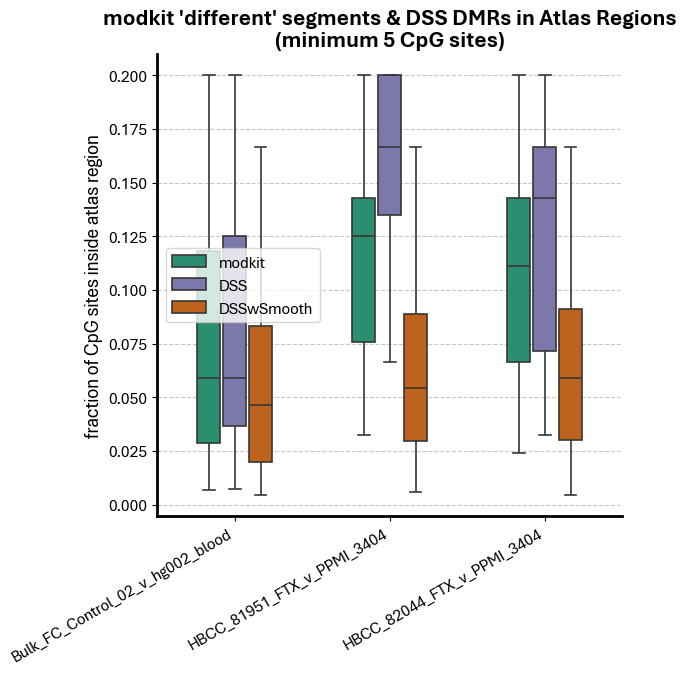

In [90]:
# -------------------------
# Settings
# -------------------------
plot_title = ("modkit 'different' segments & DSS DMRs in Atlas Regions"+
              "\n(minimum 5 CpG sites)")
test_order = ["modkit", "DSS", "DSSwSmooth"]

# colors
dark2 = mpl.colormaps["Dark2"]
set2 = mpl.colormaps["Set2"]
test_colors = dict(zip(test_order, [dark2(0), dark2(2), dark2(1)]))

plot_df = df_all_dmr_frac[(df_all_dmr_frac['n_sites'] >= 5)]
comparisons = list(pd.unique(df_all_CpG["comparison"]))

# -------------------------
# Plot: 9 violins total (3 comps x 3 tests)
# -------------------------
fig, ax = plt.subplots(figsize=(6, 6))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

sb.boxplot(data=plot_df, 
                x="comparison", 
                y="frac_inside_atlas", 
               showfliers=False,
                palette=test_colors,
                hue_order=test_order,
                width=0.5,
                gap=0.1,
               linewidth=1.2,
                hue="test")

if plot_title is not None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

# labels
ax.tick_params('both', labelsize=tick_size)
ax.set_xlabel("")
ax.set_ylabel("fraction of CpG sites inside atlas region", fontsize=label_size)
ax.set_xticks(np.arange(len(comparisons)))
ax.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)

ax.legend(fontsize=tick_size)

plt.show()

#### DMRs (bar plot)

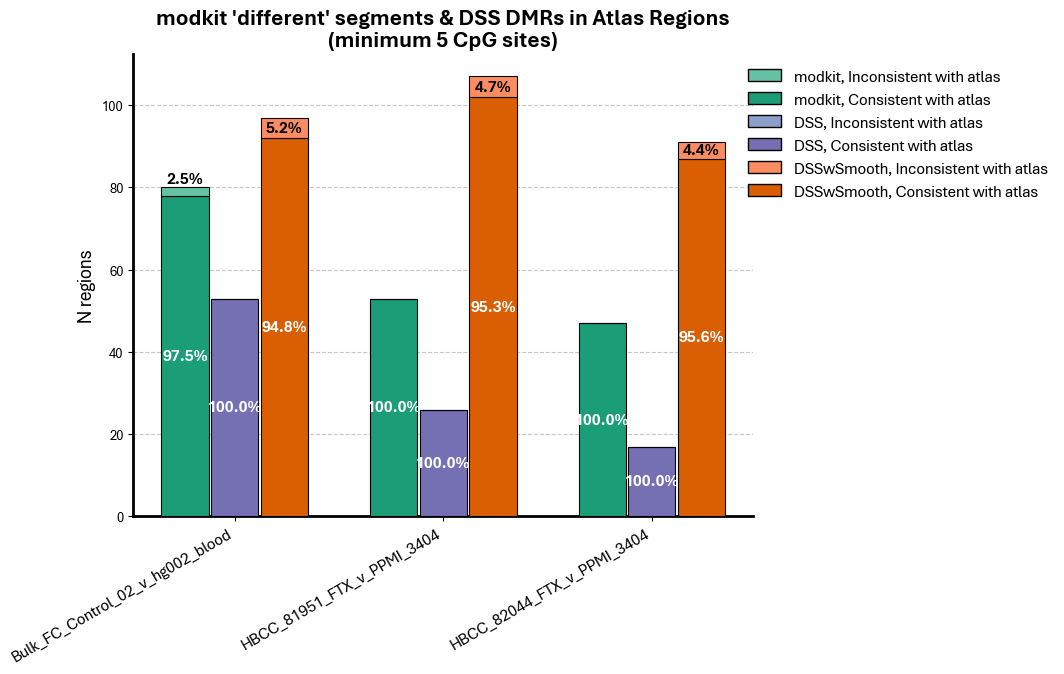

In [97]:
# -------------------------
# Settings
# -------------------------
plot_title = ("modkit 'different' segments & DSS DMRs in Atlas Regions"+
              "\n(minimum 5 CpG sites)")
test_order = ["modkit", "DSS", "DSSwSmooth"]

# colors
dark2 = mpl.colormaps["Dark2"]
set2 = mpl.colormaps["Set2"]
true_colors = dict(zip(test_order, [dark2(0), dark2(2), dark2(1)]))
false_colors = dict(zip(test_order, [set2(0), set2(2), set2(1)]))

plot_df = df_all_dmr[["comparison", "test", "n_sites", "dir_match_atlas"]].copy()
plot_df = plot_df[(plot_df['n_sites'] >= 5)]
comparisons = list(pd.unique(df_all_CpG["comparison"]))

# -------------------------
# Build counts: among significant CpGs for each test,
# stack by dir_match_atlas True/False
# -------------------------
rows = []
for comp in comparisons:
    d = plot_df.loc[plot_df["comparison"] == comp]
    for test in test_order:
        # within significant, count atlas direction match
        n_true = d[(d["test"] == test) & (d["dir_match_atlas"] == True)].shape[0]
        n_false = d[(d["test"] == test) & (d["dir_match_atlas"] == False)].shape[0]

        rows.append(
            {
                "comparison": comp,
                "test": test,
                "Consistent with atlas": n_true,
                "Inconsistent with atlas": n_false,
                "total": n_true+n_false,
            }
        )

count_long = pd.DataFrame(rows)
count_wide = (
    count_long.set_index(["comparison", "test"])[
        ["Consistent with atlas", "Inconsistent with atlas", "total"]
    ]
    .sort_index(level=["comparison", "test"])
)

# -------------------------
# Plot: 9 bars total (3 comps x 3 tests)
# stacked True (bottom) then False (top), with % labels
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)

n_tests = len(test_order)
group_gap = 1.2
bar_w = 0.95

x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_tests + group_gap)
    for k, test_name in enumerate(test_order):
        x_positions.append(base + k)

x_positions = np.array(x_positions)

# Reindex in the exact plotting order
plot_index = pd.MultiIndex.from_product(
    [comparisons, test_order], names=["comparison", "test"]
)
plot_df = count_wide.reindex(plot_index)

totals = plot_df["total"].values.astype(float)
vals_true = plot_df["Consistent with atlas"].values.astype(float)
vals_false = plot_df["Inconsistent with atlas"].values.astype(float)

# Bottom stack: True (Dark2 by test)
true_stack_colors = [true_colors[t] for (_, t) in plot_df.index]
ax.bar(
    x_positions,
    vals_true,
    width=bar_w,
    bottom=0,
    color=true_stack_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# Top stack: False (Set2 by test)
false_stack_colors = [false_colors[t] for (_, t) in plot_df.index]
ax.bar(
    x_positions,
    vals_false,
    width=bar_w,
    bottom=vals_true,
    color=false_stack_colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# Percent labels inside stacks
for i, (v_true, v_false, t) in enumerate(zip(vals_true, vals_false, totals)):
    #print(v_true, v_false)
    if t <= 0:
        continue

    if v_true > 0:
        ax.text(
            x_positions[i],
            v_true / 2,
            f"{100 * v_true / t:.1f}%",
            ha="center",
            va="center",
            fontsize=tick_size,
            fontweight="bold",
            color="white",
            zorder=5,
        )
    
    if v_false > 0:
        # put % on top if very small
        if (100 * v_false / t) < 3:
            ax.text(
                x_positions[i],
                (v_true + v_false) + 2,
                f"{100 * v_false / t:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5,
            )
        else:
            ax.text(
                x_positions[i],
                v_true + v_false / 2,
                f"{100 * v_false / t:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5,
            )

# Axis formatting: tick at middle bar of each group
mid = n_tests // 2
ax.set_xticks([x_positions[mid], x_positions[mid + n_tests], x_positions[mid + 2 * n_tests]])
ax.set_xticklabels(comparisons, rotation=30, ha="right", fontsize=tick_size)
ax.set_ylabel("N regions", fontsize=label_size)
ax.set_xlabel("")

if plot_title is not None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

# Legend: 2 stacks x 3 tests
legend_handles = []
for name in test_order:
    legend_handles.append(
        Patch(facecolor=false_colors[name], edgecolor="black", label=f"{name}, Inconsistent with atlas")
    )
    legend_handles.append(
        Patch(facecolor=true_colors[name], edgecolor="black", label=f"{name}, Consistent with atlas")
    )

ax.legend(handles=legend_handles, bbox_to_anchor=(1.5, 1), frameon=False, fontsize=tick_size)

plt.show()


#### Modkit only (bar plots)

Bin by N CpG sites

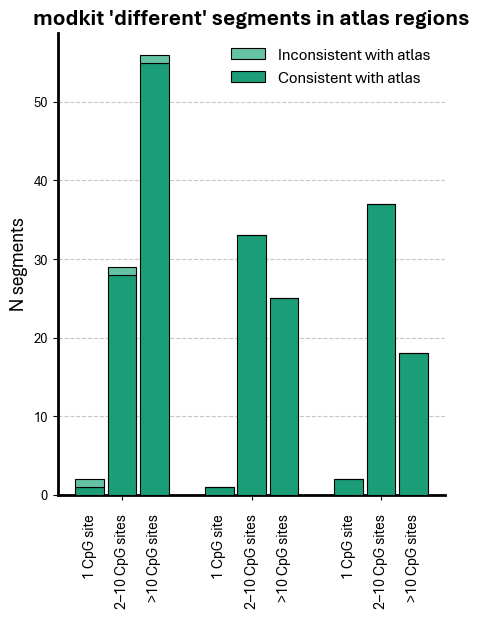

In [98]:
plot_title = "modkit 'different' segments in atlas regions"
bin_labels = ['1 CpG site', '2–10 CpG sites', '>10 CpG sites']

y_label = 'N segments'
soft_colors = [plt.cm.Dark2.colors[0], plt.cm.Set2.colors[0]]
stack_label_type = 'percent'

# -------------------------
# Build 2×(comparisons) bars by binning n_sites
# -------------------------
d0 = df_all_dmr[df_all_dmr['test'] == 'modkit'].copy()

d0["nsite_bin"] = d0["n_sites"].astype(int).apply(bin_n_sites)

# counts per (comparison, nsite_bin, dir_match_atlas)
tmp = (
    d0.groupby(["comparison", "nsite_bin", "dir_match_atlas"])
      .size()
      .unstack("dir_match_atlas", fill_value=0)
)

# make sure both stacks exist and in the right legend order
# True -> "Consistent with atlas" (bottom), False -> "Inconsistent with atlas" (top)
tmp = tmp.reindex(columns=[True, False], fill_value=0)
tmp.columns = ["Consistent with atlas", "Inconsistent with atlas"]

# wide table indexed by (comparison, nsite_bin) so we get 2 bars per comparison
count_wide = tmp.reindex(
    pd.MultiIndex.from_product([comparisons, bin_labels], names=["comparison", "nsite_bin"]),
    fill_value=0
)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

n_comp = len(comparisons)
n_bins = len(bin_labels)

intra_gap = 0.9   # spacing between the two bars in a comparison
group_gap = 0.9   # spacing between comparisons
bar_w = 0.7

# x positions: 2 bars per comparison
x_positions = []
for j, comp in enumerate(comparisons):
    base = j * (n_bins * intra_gap + group_gap)
    for k, b in enumerate(bin_labels):
        x_positions.append(base + k * intra_gap)
x_positions = np.array(x_positions)

# totals per bar for percent labels
totals = count_wide.sum(axis=1).values
bottom = np.zeros(len(count_wide), dtype=float)

for i, label in enumerate(count_wide.columns):
    values = count_wide[label].values

    ax.bar(
        x_positions,
        values,
        bottom=bottom,
        color=soft_colors[i],
        edgecolor="black",
        linewidth=0.8,
        label=label,
        zorder=4
    )

    # # stack labels
    # for bi, (v, btm, t) in enumerate(zip(values, bottom, totals)):
    #     if v == 0 or t == 0:
    #         continue

    #     if stack_label_type == 'percent':
    #         pct = 100 * v / t
    #         ax.text(
    #             x_positions[bi],
    #             btm + v / 2,
    #             f"{pct:.1f}%",
    #             ha="center",
    #             va="center",
    #             fontsize=tick_size,
    #             fontweight="bold",
    #             color="black",
    #             zorder=5
    #         )
    #     else:
    #         ax.text(
    #             x_positions[bi],
    #             btm + v / 2,
    #             f"{int(v)}",
    #             ha="center",
    #             va="center",
    #             fontsize=tick_size,
    #             fontweight="bold",
    #             color="black",
    #             zorder=5
    #         )

    bottom += values

# X ticks: center per comparison, and show two-line labels under each bar
# (optional: show comparison only, and use bar-level labels via minor ticks)
centers = np.array([j * (n_bins * intra_gap + group_gap) + (intra_gap*(n_bins-1))/2 for j in range(n_comp)])
ax.set_xticks(centers)
ax.set_xticklabels([])

# add small labels under each bar to indicate bin (1 vs >1)
for j, comp in enumerate(comparisons):
    base = j * (n_bins * intra_gap + group_gap)
    for k, b in enumerate(bin_labels):
        ax.text(
            base + k * intra_gap,
            -0.04 * ax.get_ylim()[1],
            b,
            ha="center",
            va="top",
            fontsize=tick_size - 1,
            rotation=90,
            transform=ax.transData
        )

ax.set_ylabel(y_label, fontsize=label_size)
ax.set_xlabel("")

if plot_title is not None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()


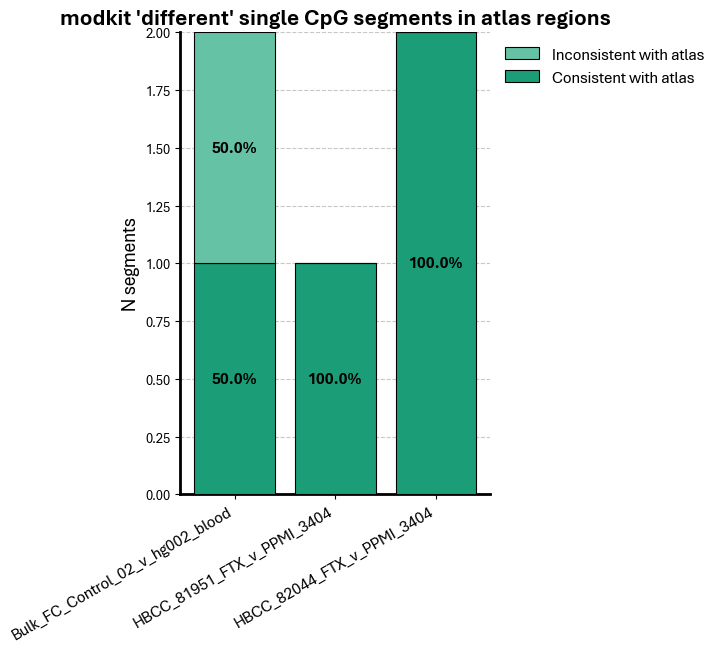

In [101]:
plot_title = "modkit 'different' single CpG segments in atlas regions"

count_wide = get_TF_counts(df_all_dmr[(df_all_dmr['test'] == 'modkit') & (df_all_dmr['n_sites'] == 1)], 
                            'dir_match_atlas', 
                           ["Consistent with atlas", "Inconsistent with atlas"])

y_label = 'N segments'
soft_colors = [plt.cm.Dark2.colors[0], plt.cm.Set2.colors[0]]
stack_label_type = 'percent'

fig, ax = plt.subplots(figsize=(4, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

x = np.arange(count_wide.shape[0])
bottom = np.zeros(count_wide.shape[0])
totals = count_wide.sum(axis=1).values

for i, label in enumerate(count_wide.columns):
    values = count_wide[label].values
        
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=soft_colors[i],
        edgecolor="black",
        linewidth=0.8,
        label=label,
        zorder=4
    )

    # stack labels
    for i, (v, b, t) in enumerate(zip(values, bottom, totals)):
        if v == 0:
            continue
        
        if stack_label_type == 'percent':
            pct = 100 * v / t
            ax.text(
                x[i],
                (b + v / 2),
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5)
        else:
            ax.text(
                x[i],
                b + v / 2,
                v,
                ha="center",
                va="center",
                fontsize=tick_size,
                fontweight="bold",
                color="black",
                zorder=5)

    bottom += values

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(count_wide.index, rotation=30, ha="right", fontsize=tick_size)
ax.set_ylabel(y_label, fontsize=label_size)
ax.set_xlabel("")

if plot_title != None:
    ax.set_title(plot_title, fontweight="bold", fontsize=title_size)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1, 1), frameon=False, fontsize=tick_size)

plt.show()

#### Find washed out DMR examples

In [102]:
# atlas regions in promoters
promoter_atlas_locs = set(df0_chromhmm[(df0_chromhmm['state_class'] == 'Promoter')]['location'])
print(len(promoter_atlas_locs))

# atlas regions that are correct with smoothing
smooth_atlas_locs = set(df_all_dmr[(df_all_dmr['test'] == 'DSSwSmooth') &
                                (df_all_dmr['dir_match_atlas'])]['location'])
print(len(smooth_atlas_locs))

print(len(promoter_atlas_locs & smooth_atlas_locs))

80
122
57


In [109]:
df_search = df_all_dmr[(df_all_dmr['n_sites'] >= 5) & 
            # (df_all_dmr['location'].isin(promoter_atlas_locs)) &
            (~df_all_dmr['location'].isin(smooth_atlas_locs)) &
            (df_all_dmr['test'].isin(['modkit', 'DSS'])) & 
            # (df_all_dmr['comparison'] == 'HBCC_81951_FTX_v_PPMI_3404') &
            (df_all_dmr['dir_match_atlas'])]

df_search[df_all_dmr['location'].duplicated(keep=False)].sort_values(['location', 'test']).head(30)

/tmp/ipykernel_2905092/1483425603.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_search[df_all_dmr['location'].duplicated(keep=False)].sort_values(['location', 'test']).head(30)


,chr,start,end,n_sites,comparison,test,effect_size,stat,best_group,best_dir,location,dir_match_atlas,length
316,chr20,37037697,37037831,5,HBCC_81951_FTX_v_PPMI_3404,DSS,0.662134,31.258091,Blood-Granul,hypo,chr20:37037698-37037832,True,134
504,chr20,37037697,37037831,5,HBCC_82044_FTX_v_PPMI_3404,DSS,0.642901,27.137468,Blood-Granul,hypo,chr20:37037698-37037832,True,134
277,chr20,37037697,37037831,5,HBCC_81951_FTX_v_PPMI_3404,modkit,0.683472,1.709972,Blood-Granul,hypo,chr20:37037698-37037832,True,134
471,chr20,37037697,37037831,5,HBCC_82044_FTX_v_PPMI_3404,modkit,0.669916,1.624067,Blood-Granul,hypo,chr20:37037698-37037832,True,134
